# Day 2 Session 4: Optimization and Gradient Descent

**Time:** 2:30-3:45  
**Theme:** Use gradients and iterative updates to optimize loss functions when grid search becomes expensive.

**Instructor emphasis:** Emphasize the update rule, learning rate, and why local minima can matter before moving to automatic differentiation.

---

## Suggested pacing

| Time | Notebook section | Activity | Priority |
|---|---|---|---|
| 2:30-2:40 | Motivation for optimization | Explain why grid search becomes costly in larger parameter spaces | Core |
| 2:40-2:55 | Gradient descent idea | Connect gradients to small steps that reduce a loss function | Core |
| 2:55-3:10 | Two-dimensional examples | Visualize local minima and discuss starting values | Core |
| 3:10-3:30 | JAX gradients | Use automatic differentiation to compute update directions | Core |
| 3:30-3:40 | Parameter-fitting example | Connect gradient-based fitting back to model-data mismatch | Core |
| 3:40-3:45 | Bridge to Day 3 | Preview likelihood, random walks, and MCMC | Core |

> **Pacing note:** Keep the JAX section focused on the workflow rather than syntax details. The main goal is to show why gradients can replace exhaustive search.

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import jax.numpy as jnp
import jax
import pandas as pd

In [2]:
github_url = "https://raw.githubusercontent.com/AZDSC-NAU/AZDSC_NAU_SITE/master/project_1/fictious_data.csv"

data = pd.read_csv(github_url)

print(data.shape) #(rows,columns)

data.head() ## Prints the first few rows of the dataframe

(212, 2)


,date,count
0,2025-10-01,3
1,2025-10-02,7
2,2025-10-03,3
3,2025-10-04,4
4,2025-10-05,10


### Optimization

In 1 and 2 dimensional parameter spaces we can often do this grid search to find optimal parameter values. However in higher dimensions performing a grid search becomes extremely costly. We therefore need smarter techniques for identifying the minimum of our loss function. 

Many techniques exist for optimizing loss functions, including metaheuristic algorithms like Particle Swarm Optimization or Ant Colony Optimization. In addition, machine learning commonly makes use of differentiable loss functions whose gradients can be used to make intelligent steps. 

Instead of identifying minimum values in a single step, many optimization algorithms take small steps in the parameter space until some convergence criteria is reached. As an illustrative example we will now consider gradient descent. 

#### Gradient Descent

Gradient descent is a technique for finding the minimums of functions which involves taking many small steps in the direction of steepest descent. Mathematically we write 

$$
\theta_{n+1} = \theta_{n} - \eta \nabla \mathcal{L}(\theta_{n})
$$

Where $\theta_{n}$ is the current best guess for the parameters which minimize $\mathcal{L}$, $\eta$ is a parameter that controls the step size, and $\nabla \mathcal{L}(\theta_{n})$ is a vector called the gradient. The gradient is defined as 

$\nabla \mathcal{L}(\theta) = [\frac{\partial \mathcal{L}}{\partial \theta^{1}},\dots,\frac{\partial \mathcal{L}}{\partial \theta^{k}}]$ where the index of $\theta^{i}$ ranges from $0$ to $k$. 

The idea of the gradient is that for any scalar function the gradient tells us the direction to move to increase the value of the function as quickly as possible. 

For example, take the function $f(x,y) = e^{-(x^2 + y^2)}$ plotted below.


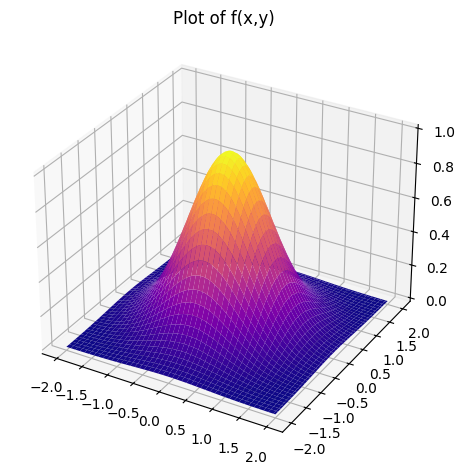

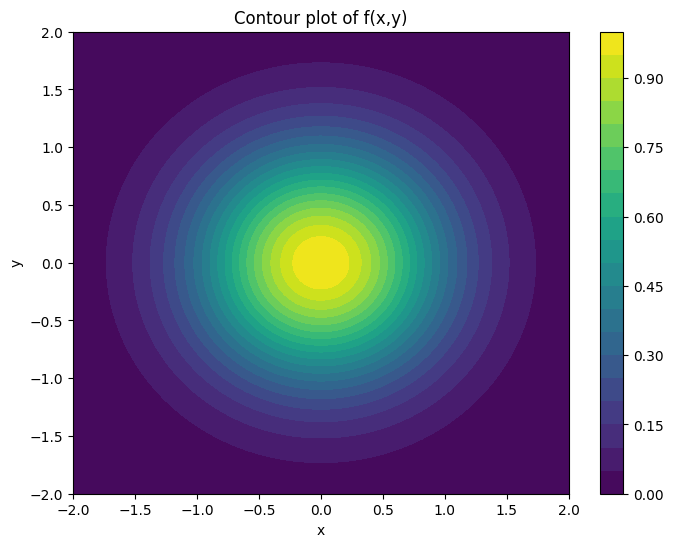

In [3]:
from matplotlib import cm

spacing = 0.01
xy_range = np.arange(-2, 2 + spacing, spacing)
X, Y = np.meshgrid(xy_range, xy_range)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Plot of f(x,y)")
ax.plot_surface(X, Y, np.exp(-(X**2 + Y**2)), cmap=cm.plasma)
fig.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.title("Contour plot of f(x,y)")
plt.contourf(X, Y, np.exp(-(X**2 + Y**2)), cmap="viridis", levels=20)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.show()


We can see this function has a maximum at $(0,0)$. Suppose we have are starting at a point $(x_0,y_0)$ and we want to take a series of small steps towards the maximum. We can compute the gradient 

$$
\begin{align*}
\nabla \mathcal{f}(x,y) &= \left[\frac{\partial f}{\partial x},\frac{\partial f}{\partial y}\right] \\
&= \left[\frac{\partial}{\partial x}\left(e^{-(x^2 + y^2)}\right),\frac{\partial}{\partial y}\left(e^{-(x^2 + y^2)}\right) \right] \\
&= \left[-2x e^{-(x^2 + y^2)},-2y e^{-(x^2 + y^2)}\right].
\end{align*}
$$

This gives us a vector for each point in the domain of $f$. If we take a step along that vector we will increase the function value as quickly as possible. Let's visualize this.

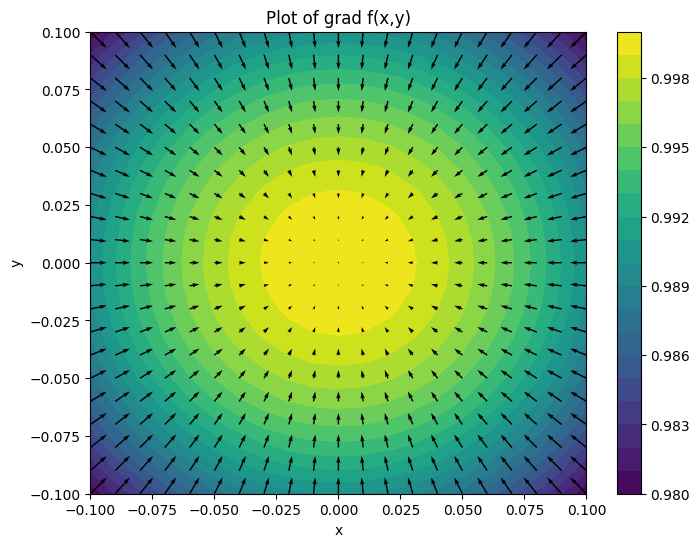

In [4]:
plt.figure(figsize=(8, 6))
plt.title("Plot of grad f(x,y)")

def grad_f(x, y):
    return np.array([-2 * x * np.exp(-(x**2 + y**2)), -2 * y * np.exp(-(x**2 + y**2))])

xy_range = np.arange(-0.1, 0.1 + spacing, spacing)
X, Y = np.meshgrid(xy_range, xy_range)
plt.contourf(X, Y, np.exp(-(X**2 + Y**2)), cmap="viridis", levels=20)
plt.colorbar()
U,V = grad_f(X,Y)
plt.quiver(X,Y,U,V)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

We can imagine a particle moving in this flow field. If we let the particle flow for a long enough time it will approach the maximum of the function. 
Using gradient ascent we can take small steps in the direction of the gradient, approximating this flow. Recall $\theta_n = [x_n,y_n]$ where $n$ is the n-th step of the algorithm. We can write 

$$
\theta_{n+1} = \theta_{n} + \eta \nabla \mathcal{f}(\theta_{n}). 
$$

Since the gradient points in the direction of steepest ascent if want to find the maximum of the function we can step in the direction of the gradient. Similarly if we want to find the minimum of the function we can step in the opposite direction as the gradient or $-\nabla f(\theta_n)$.

### Exercise 1

Use a simple gradient descent in python to identify the minimum of $f(x,y) = x^2 + 3y^2$. 

Step 1: Calculate the gradient algebraically. 

Step 2: Implement the gradient descent. Be sure to watch the sign of the step!
    Define 3 functions, `f`, `grad_f`, and `gradient_descent`. 
    `f` will have signature `f(x,y)` and return a single value. 
    `grad_f` will have signature `f(x,y)` and two outputs. 
    `gradient descent` will have signature `gradient_descent(steps, step_size, init_x, init_y, grad_f)` and return a matrix of shape (steps, 2) where each row corresponds to a step and each column to the value of $(x_n,y_n)$.

Step 3: Use the gradient descent to find the minimum of the function. 
    What happens if you change the step size to $0.01,0.1,1.0$? How many steps are needed for convergence in each case?

In [5]:
def f(x, y):
    # TODO
    # Define f = x^2 + 3y^2
    return x + y


def grad_f(x, y):
    # TODO
    # Define the gradient of f, returning the two partial derivatives
    return x, y


def gradient_descent(steps, step_size, init_x, init_y, grad_f, sign):
    # Note that sign = 1.0 if doing gradient ascent and -1.0 if doing gradient descent. 
    points_visited = np.zeros((steps, 2))
    points_visited[0, :] = np.array([init_x, init_y])
    for step in range(1, steps):
        prev_point = points_visited[step - 1, :]

        #TODO 
        # Implement the gradient descent formula using the step size and grad_f
        # theta_{n+1} will correspond to curr_point

        points_visited[step, :] = curr_point

    return points_visited

Let's try this on another slightly more complicated function. This function illustrates an issue with gradient descent, that if there are multiple local optima gradient descent can get stuck in one. 


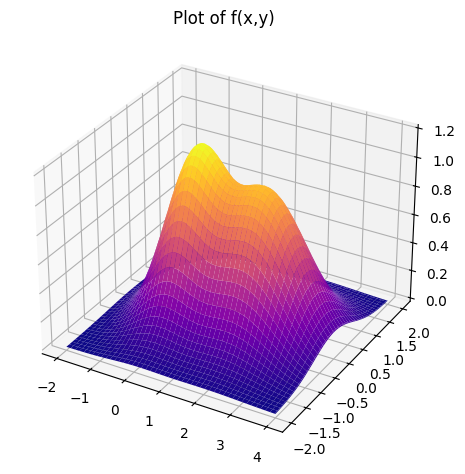

NameError: name 'curr_point' is not defined

In [6]:
def f(x, y):
    return np.exp(-(x**2 + y**2)) + np.exp(-(((x - 2) / 1.5) ** 2 + y**2))


steps = 100
step_size = 0.1


def grad_f(x, y):
    exp1 = np.exp(-(x**2 + y**2))
    exp2 = np.exp(-(4 / 9) * (x - 2) ** 2 - y**2)

    df_dx = -2 * x * exp1 - (8 / 9) * (x - 2) * exp2
    df_dy = -2 * y * exp1 - 2 * y * exp2

    return np.array([df_dx, df_dy])


x_range = np.arange(-2, 4 + spacing, spacing)
y_range = np.arange(-2, 2 + spacing, spacing)
X, Y = np.meshgrid(x_range, y_range)
vals = f(X, Y)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Plot of f(x,y)")
ax.plot_surface(X, Y, vals, cmap=cm.plasma)
fig.tight_layout()
plt.show()

points_visited = gradient_descent(steps, step_size, 3.0, 0.0, grad_f, 1.0)

plt.figure(figsize=(8, 6))
plt.title("Plot of f(x,y)")

plt.contourf(X, Y, vals, 20)
plt.scatter(points_visited[:, 0], points_visited[:, 1], color="red", zorder=100, s=1.0)
plt.colorbar()
U, V = grad_f(X, Y)
plt.quiver(X, Y, U, V)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

We see that certain starting points converge to a local maximum, but not the global maximum of the function. There are various advanced techniques to address this, however for now we will assume our functions only have one gloabl maximum and no local maxima. 



By taking steps in the direction of the gradient we approach a local maximum of our function. This technique is highly effective, however it requires manually calcuating the gradient for each function we want to optimize. For our loss function $\mathcal{L}$ this is clearly not possible as the algebraic expression is too complicated to write down. 






### Automatic Differentiation
Using modern machine learning libraries we can differentiate functions that are written in python with only a few lines of code. JAX is developed by Google and can serve as an (almost) drop in replacement for NumPy. The advantage of JAX is that it can allow us to compute derivatives of the functions we define using automatic differentiation. 



### Exercise 2

Use our gradient descent function from step 1 to find the minimum of the function $f(x,y) = (1-x)^2 + 100(y-x^2)^2$. 

Step 1: Define intermediate expressions and sketch the compute graph. 

Step 2: Calculate the gradient algebraically. 

Step 3: Implement the gradient in python using both autodiff and the algebraic expression. 

Step 4: Perform gradient descent using both techniques and compare the results. How many steps are needed for convergence, and how small must the step size be? 

In [ ]:
def f(x, y):
    # TODO
    # Define f = x^2 + 3y^2
    return x + y


def grad_f_numpy(x, y):
    # TODO
    # Define the gradient of f, returning the two partial derivatives
    return x, y

#TODO 
# Define the gradient using jax 

#TODO
# Set the number of steps and step size appropriately. 

steps = 0
step_size = 0

points_visited_numpy = gradient_descent(steps, step_size, 1.0, -1.0, grad_f_numpy)
points_visited_jax = gradient_descent(steps, step_size, 1.0, -1.0, grad_f_jax)

spacing = 0.1
x_range = np.arange(-2, 2 + spacing, spacing)
y_range = np.arange(-1.5, 3 + spacing, spacing)
X, Y = np.meshgrid(x_range, y_range)
vals = f(X, Y)
U, V = grad_f(X, Y)
plt.contourf(X, Y, vals, levels=np.logspace(0, 3, 20), cmap="viridis", extend="both")
plt.quiver(X, Y, -U, -V)
plt.scatter(points_visited_numpy[:, 0], points_visited_numpy[:, 1], s=2.0, color="red")
plt.scatter(points_visited_jax[:, 0], points_visited_jax[:, 1], s=1.0, color="green")
plt.colorbar()
plt.show()

### Gradient Descent on the Loss Function 

To make the loss function compatible with JAX we need to modify our model slightly. Note that the loop has been replaced with the `jax.lax.scan`. Let's also recall our fictious noisy data which was generated from an SIR model with $\beta = 0.15$ and $\gamma = 0.1$. 

In [ ]:
numpy_data = data['count'].to_numpy() #Convert Pandas column to numpy array

plt.figure(figsize = (8,6))
plt.title('Noisy Infections')
plt.scatter(np.arange(0,len(data)),numpy_data,marker = 'x',color = 'tab:red')
plt.xlabel('Days')
plt.ylabel('Infections')
plt.show()

In [ ]:
#Right hand side of SIR model
def sir_rhs(X,params):
    S,I,R = X
    N = S + I + R
    beta,gamma = params 
    dS = -beta * S * I/N
    dI = beta * S * I/N - gamma * I
    dR = gamma * I
    return jnp.array([dS,dI,dR])

#Runs the model in a loop
def model(rhs,x0,ts,par):
    delta_t = ts[1]-ts[0] 

    def scan_fn(carry,t_index): 
        x_prev = carry
        x_curr = x_prev + delta_t * rhs(x_prev,par)
        return x_curr,x_curr

    _,ys = jax.lax.scan(scan_fn,init = x0,xs = ts)

    return ys

In [ ]:
#Define the loss function, we will only differentiate with respect to par_prop as the data is fixed. 
def loss(par_prop,data):
    x0 = jnp.array([495.,5.,0.])
    delta_t = 0.01
    ts = jnp.arange(0,len(data),delta_t)
    sol_prop = model(sir_rhs,x0,ts,par_prop)
    return jnp.sum((data - sol_prop[::int(1/delta_t),1])**2) 

numpy_data = data['count'].to_numpy() #Convert Pandas column to numpy array

loss((0.3,0.1),numpy_data)

Let's test the loss function gradient to make sure it works. 

In [ ]:
loss_grad = jax.grad(loss)
loss_grad((0.3,0.1),numpy_data)

We see our gradient has two elements, this is exactly what we want. Now let's run gradient descent and visualize the results on the contours of our loss function. 

In [ ]:
from matplotlib.colors import LogNorm

steps = 150
step_size = 1e-8
spacing = 0.01


points_visited = np.zeros((steps, 2))
points_visited[0, :] = np.array([0.4, 0.1])
for step in range(1, steps):
    prev_point = points_visited[step - 1, :]
    curr_point = prev_point - step_size * loss_grad(prev_point, numpy_data)
    points_visited[step, :] = curr_point

param_range = np.arange(0, 0.5 + spacing, spacing)
B, G = np.meshgrid(param_range, param_range)
BG_stacked = jnp.concatenate((G[..., None], B[..., None]), axis=-1)
loss_vals = jax.vmap(jax.vmap(loss, in_axes=(0, None)), in_axes=(1, None))(
    BG_stacked, numpy_data
)

plt.figure(figsize=(8, 6))
plt.title("Contour Plot of the Loss Function")
plt.contourf(
    B,
    G,
    loss_vals,
    levels=np.logspace(np.log10(loss_vals.min()), np.log10(loss_vals.max()), 50),
    norm=LogNorm(),
    cmap="viridis",
)

plt.colorbar()
plt.plot(param_range,param_range, ls = 'dashed',color = 'green')
plt.scatter(points_visited[:, 0], points_visited[:, 1], color="red", zorder=100, s=1.0)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\gamma$")
plt.show()

print(f"Optimal Param Estimate: {points_visited[-1]}")

We can see our algorithm iteratively approaches the minimum of the function as long as our step along the gradient is sufficiently small. Because the gradient of our loss function is very large we must make very small steps. 